# T05 — Comparing rotation models: how the choice of plate reconstruction redraws paleo-geography

**Reconstruct a dense global grid to 410 Ma and 370 Ma using two independent rotation models (Zahirovic 2022 and Merdith 2021) and visualise (a) the side-by-side paleo-geography in each model and (b) the per-point great-circle displacement between the two models' predicted paleo-positions at each age. The hot regions on the displacement map identify exactly where the rotation-model choice matters most for any downstream analysis at that age.**

## What this notebook produces

Most users of plate reconstructions never treat the rotation model itself as a free parameter — they pick a model, run a reconstruction, accept the output. This notebook makes the model choice an explicit variable. We pick two snapshot ages in the Paleozoic (410 Ma, late Silurian; 370 Ma, early Late Devonian (Frasnian)), reconstruct continents and a dense global sampling grid through *both* models at each age, and produce:

- A **side-by-side paleo-Earth map per model per age** (2 × 2) showing how each model places the continents.
- A **per-snapshot quantitative displacement map** — for each sampled point, the great-circle distance in km between its position in Zahirovic 2022 and its position in Merdith 2021 at the same age. Median, 95th-percentile, and maximum displacement are also printed.

The displacement map is the headline diagnostic: large displacements signal regions where the model-choice contributes substantially to paleo-position uncertainty — the rotation-frame-induced floor on what any downstream analysis (paleomag fit, paleoclimate, paleo-biogeography) can resolve at that age.

## Why these two models?

Cao 2024 was intentionally not chosen here because it *inherits* Merdith 2021's rotation chain for ages beyond ~250 Ma — comparing them in deep time would just confirm that Cao = Merdith by construction. Zahirovic 2022 is an independent Phanerozoic-only plate model (0-410 Ma) built from a different starting point, so it gives a genuine model-vs-model contrast against Merdith in the Paleozoic. Both ages chosen (410 + 370 Ma) fall inside Zahirovic 2022's coverage window.

## Why this matters

The "rotation model" is the single biggest non-data-driven choice a paleo-reconstruction-using study makes. Two compilations built from the same underlying paleomag + geological constraints will still differ by tens of km at well-sampled times and hundreds to thousands of km in older, sparsely-sampled intervals. Knowing which side of that range a study sits on is necessary for honest uncertainty propagation.

**Audience**: postgrad.
**Difficulty**: ★★★.

## Learning objectives

- Load multiple plate models in the same session via `plate_model_manager` and build a separate `gplately.PlateReconstruction` for each.
- Produce side-by-side paleo-Earth maps under different rotation models for the same age.
- Quantify and visualise the per-point displacement between two rotation models' predictions for a sampled grid.
- Read the displacement map regionally — equator-crossing, polar drift, and rifting/colliding plate margins typically have the largest model-to-model spread.

## Prerequisites and runtime

- Plate models: Zahirovic 2022 + Merdith 2021 — both fetched automatically by `plate_model_manager`.
- Python: `gplately`, `pygmt`, `pygplates`, `numpy`. No special bundled data needed.
- Runtime: a few seconds end-to-end once PMM has downloaded the models on first use.


## Data availability — how to get the bundled netCDFs

This notebook reads time-dependent mantle / dynamic-topography
netCDFs from Santosh Dhungana's online supplement to
**Dhungana & Flament (2025) (https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity) — *The Deep Earth Origin of the Great
Unconformity***, soon to appear in *Journal of Geophysical Research —
Solid Earth*. The dataset is hosted in his GitHub repository, which
uses Git LFS for the binary files:

> https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity

The fields used by this notebook are too large to bundle into the
tutorial suite (multi-100 MB per cube, with sibling files totalling
GB-scale). To run T05 end-to-end, clone Santosh's repo (https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity)
with Git LFS:

```bash
# one-time install (macOS: brew install git-lfs; Linux: apt install git-lfs)
git lfs install

# then clone normally — LFS pull is automatic
git clone https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity
```

then set `SANTOSH_REPO` in the CONFIGURATION cell below to the local
path of your clone. The specific files this notebook reads are listed
in the cell after configuration, so you can confirm they exist before
running the rest of the workflow:


- `EDF7_Data/reconstructed_gld504_DT_*MA_504.nc` — eight pre-reconstructed DT snapshots
  (220 / 540 Ma, 504 plate IDs)
- `EDF7_Data/cluster_gld504_*MA.nc` — pre-computed cluster outputs at the same ages
- `Reconstructions/Scotese_paleogeography/Reconstruction/PALEOMAP (https://www.earthbyte.org/paleodem-resource-scotese-and-wright-2018/)GlobalPlateModel` —
  the alternative Scotese rotation tree compared against
- These are the EDF7_Data files specifically — about 8 × 5 MB = 40 MB total. The
  smallest LFS pull of the set, useful as a starter test.


## Upstream data citations

- **Mantle-flow simulations** used by Dhungana & Flament rest on Müller
  et al.'s (2022) tectonic-rules-based mantle reference frame:
  https://doi.org/10.5194/se-13-1127-2022
- **Deep-time plate kinematics** used by the M2020 / Merdith
  reconstructions are from Merdith et al. (2021):
  https://doi.org/10.1016/j.earscirev.2020.103477
- **Late-Precambrian to Phanerozoic boundary kinematics** used by Cao
  2024 are from Cao et al. (2024): https://doi.org/10.5194/essd-16-4007-2024

When you publish a result derived from this notebook, please cite the
Dhungana & Flament (2025) paper for the dataset, the upstream Müller /
Merdith / Cao paper for whichever rotation model you used, and the
GPlately + pyGMT papers (Mather et al.  (https://github.com/brmather/SeafloorAnomalies)2024; Tian et al. 2024)
for the software stack.

In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import numpy as np, xarray as xr
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration — change which two models to compare here

In [2]:
# === USER CONFIGURATION =====================================================
# Why these two? Cao 2024 inherits Merdith 2021's rotations for ages
# beyond ~250 Ma — comparing them in deep time would just confirm that
# Cao = Merdith by construction. Zahirovic 2022 is an INDEPENDENT
# Phanerozoic plate model (0-410 Ma) developed from a different
# starting point, so it gives a meaningful model-vs-model contrast
# against Merdith in the Paleozoic. Snapshot ages are chosen inside
# Zahirovic's coverage window.
MODEL_A  = "Zahirovic2022"
MODEL_B  = "Merdith2021"
SNAPSHOT_TIMES = (410.0, 370.0)   # Ma — late Silurian + early Late Devonian
# 
# --- Santosh's data root (see Data availability cell above) ---
import os
from pathlib import Path
# === SANTOSH_REPO — point this at your local clone =========================
SANTOSH_REPO = os.environ.get(
    "SANTOSH_REPO",
    str(Path("./external/Dynamic-Topography-and-Great-Unconformity")),
)
# ============================================================================


## 1. Load both rotation models and the DT cube

In [3]:
# Cell 2 — load both rotation models
# The notebook compares MODEL_A vs MODEL_B side-by-side at each snapshot
# age. We load both models from the Plate Model Manager and build a
# gplately.PlateReconstruction for each. We also keep the raw model
# objects (mA, mB) around because the renderer in Cell 3 needs them
# for get_coastlines() / get_continental_polygons() / get_COBs().
pmm = PlateModelManager()

mA = pmm.get_model(MODEL_A, data_dir="./gplately_data")
mB = pmm.get_model(MODEL_B, data_dir="./gplately_data")

reconA = gplately.PlateReconstruction(
    rotation_model=mA.get_rotation_model(),
    topology_features=mA.get_topologies(),
    static_polygons=mA.get_static_polygons(),
)
reconB = gplately.PlateReconstruction(
    rotation_model=mB.get_rotation_model(),
    topology_features=mB.get_topologies(),
    static_polygons=mB.get_static_polygons(),
)

engine = gplately.PygmtPlotEngine()

print(f"  loaded rotation models:")
print(f"    A: {MODEL_A}  (mA, reconA)")
print(f"    B: {MODEL_B}  (mB, reconB)")
print(f"  snapshot ages: {SNAPSHOT_TIMES}")


  loaded rotation models:
    A: Zahirovic2022  (mA, reconA)
    B: Merdith2021  (mB, reconB)
  snapshot ages: (410.0, 370.0)


## 2. Render the 2×2 grid of paleo-Earth maps

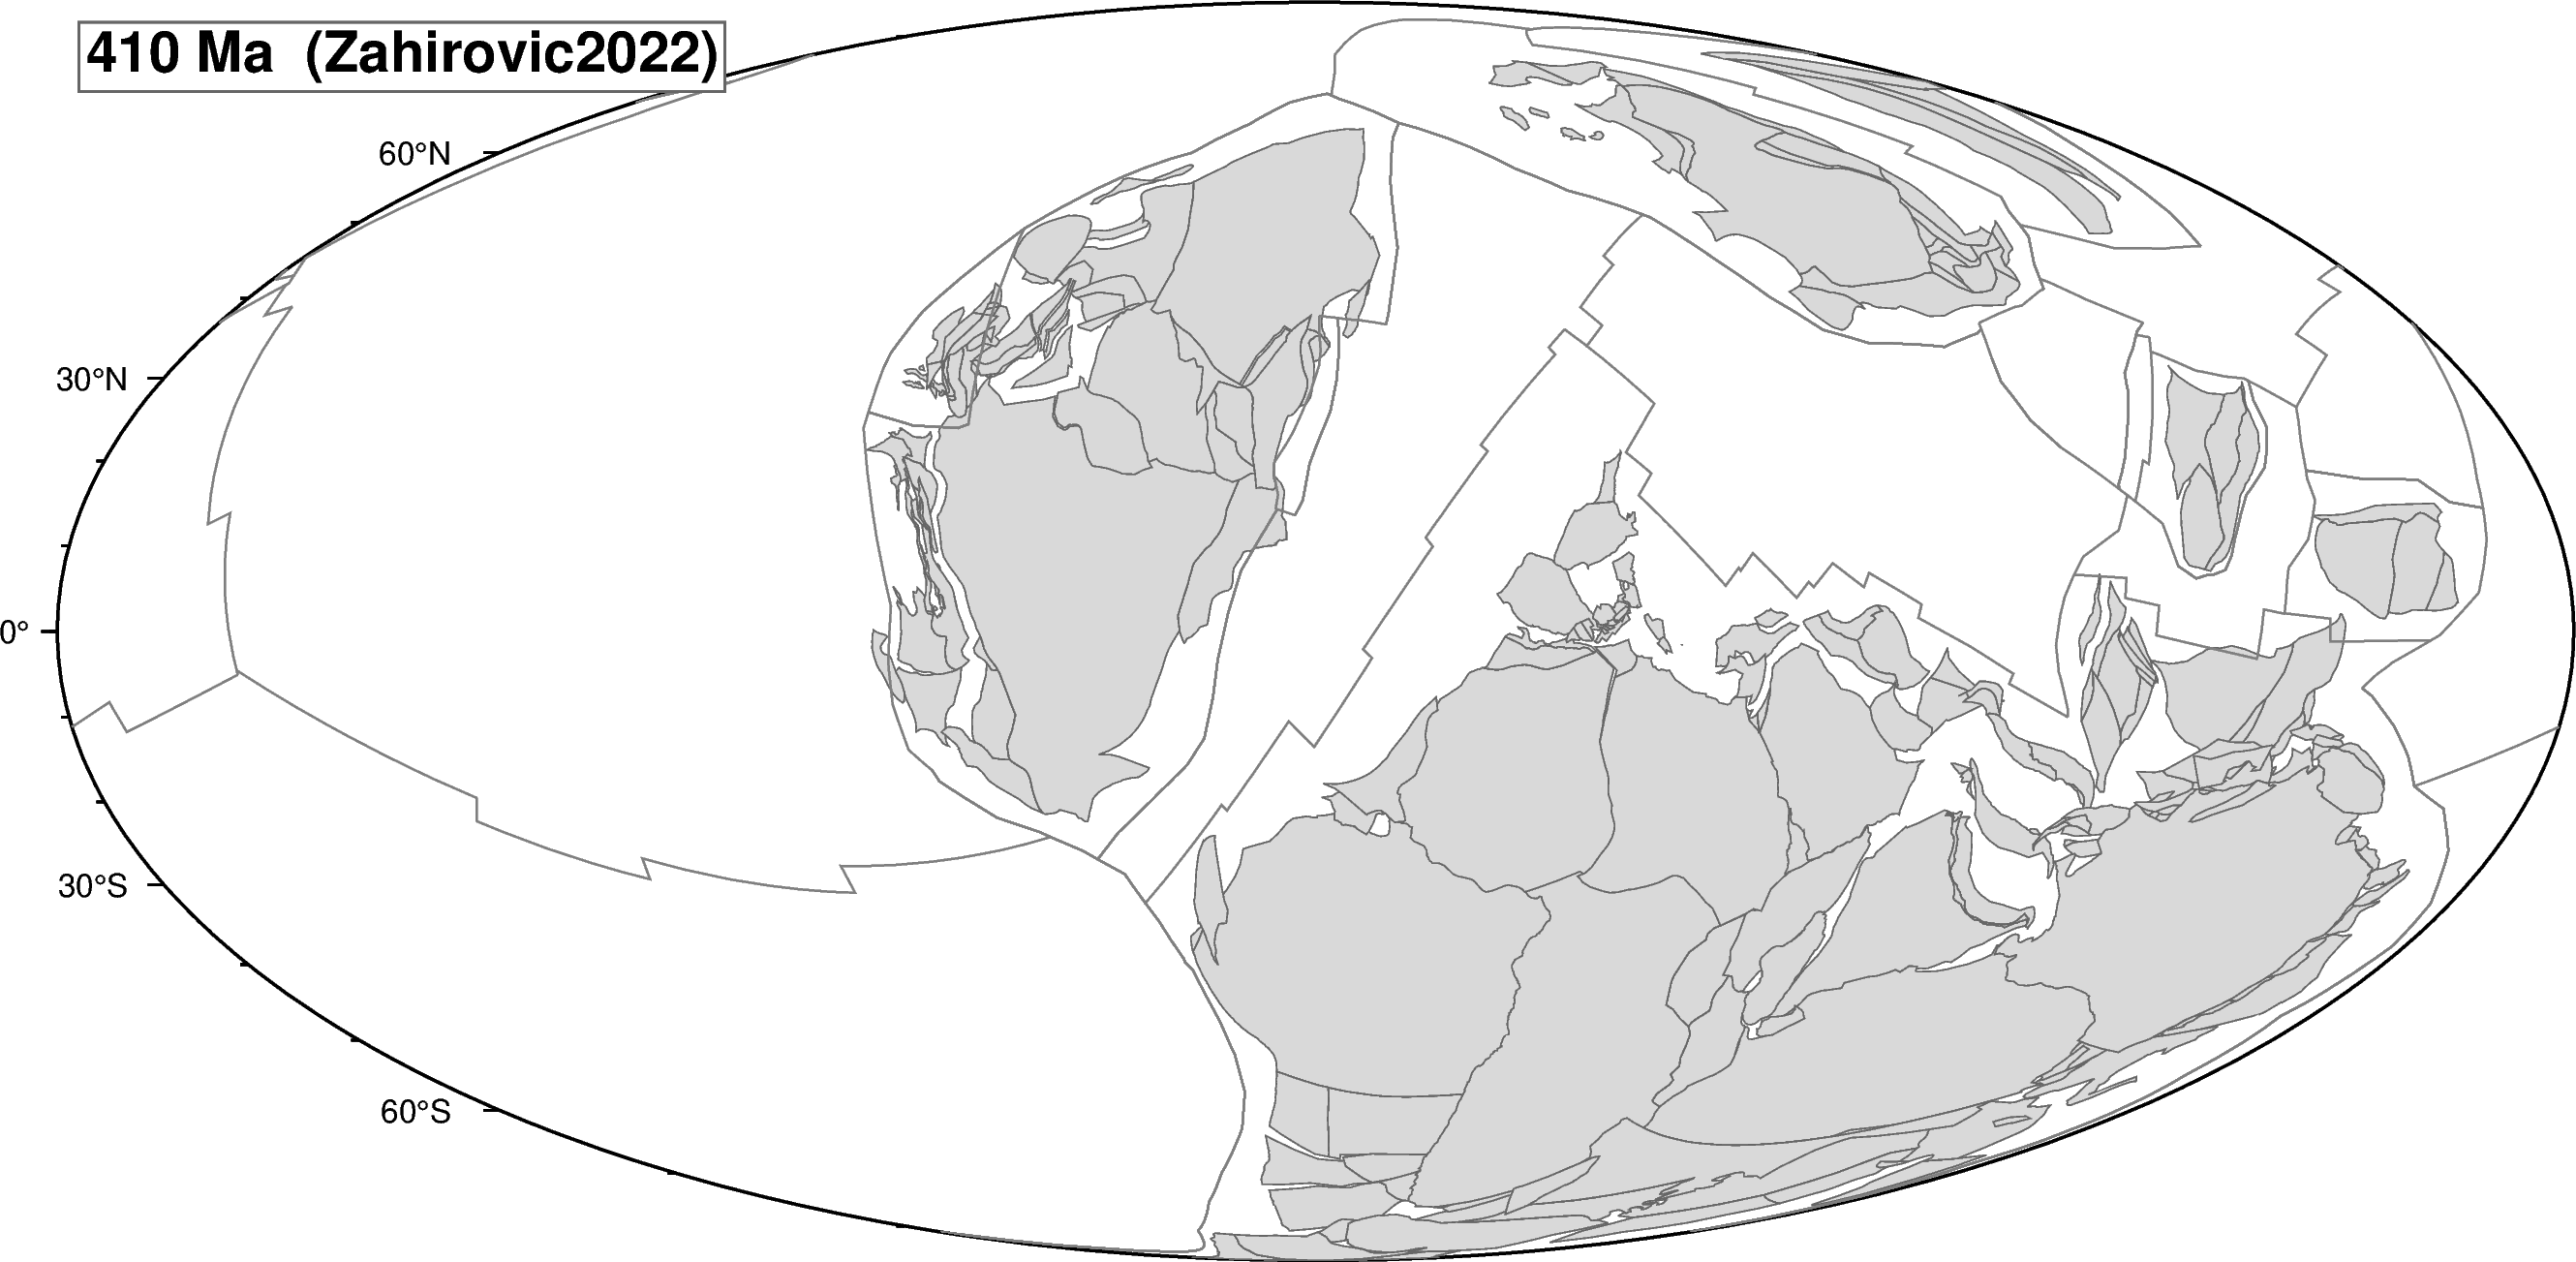

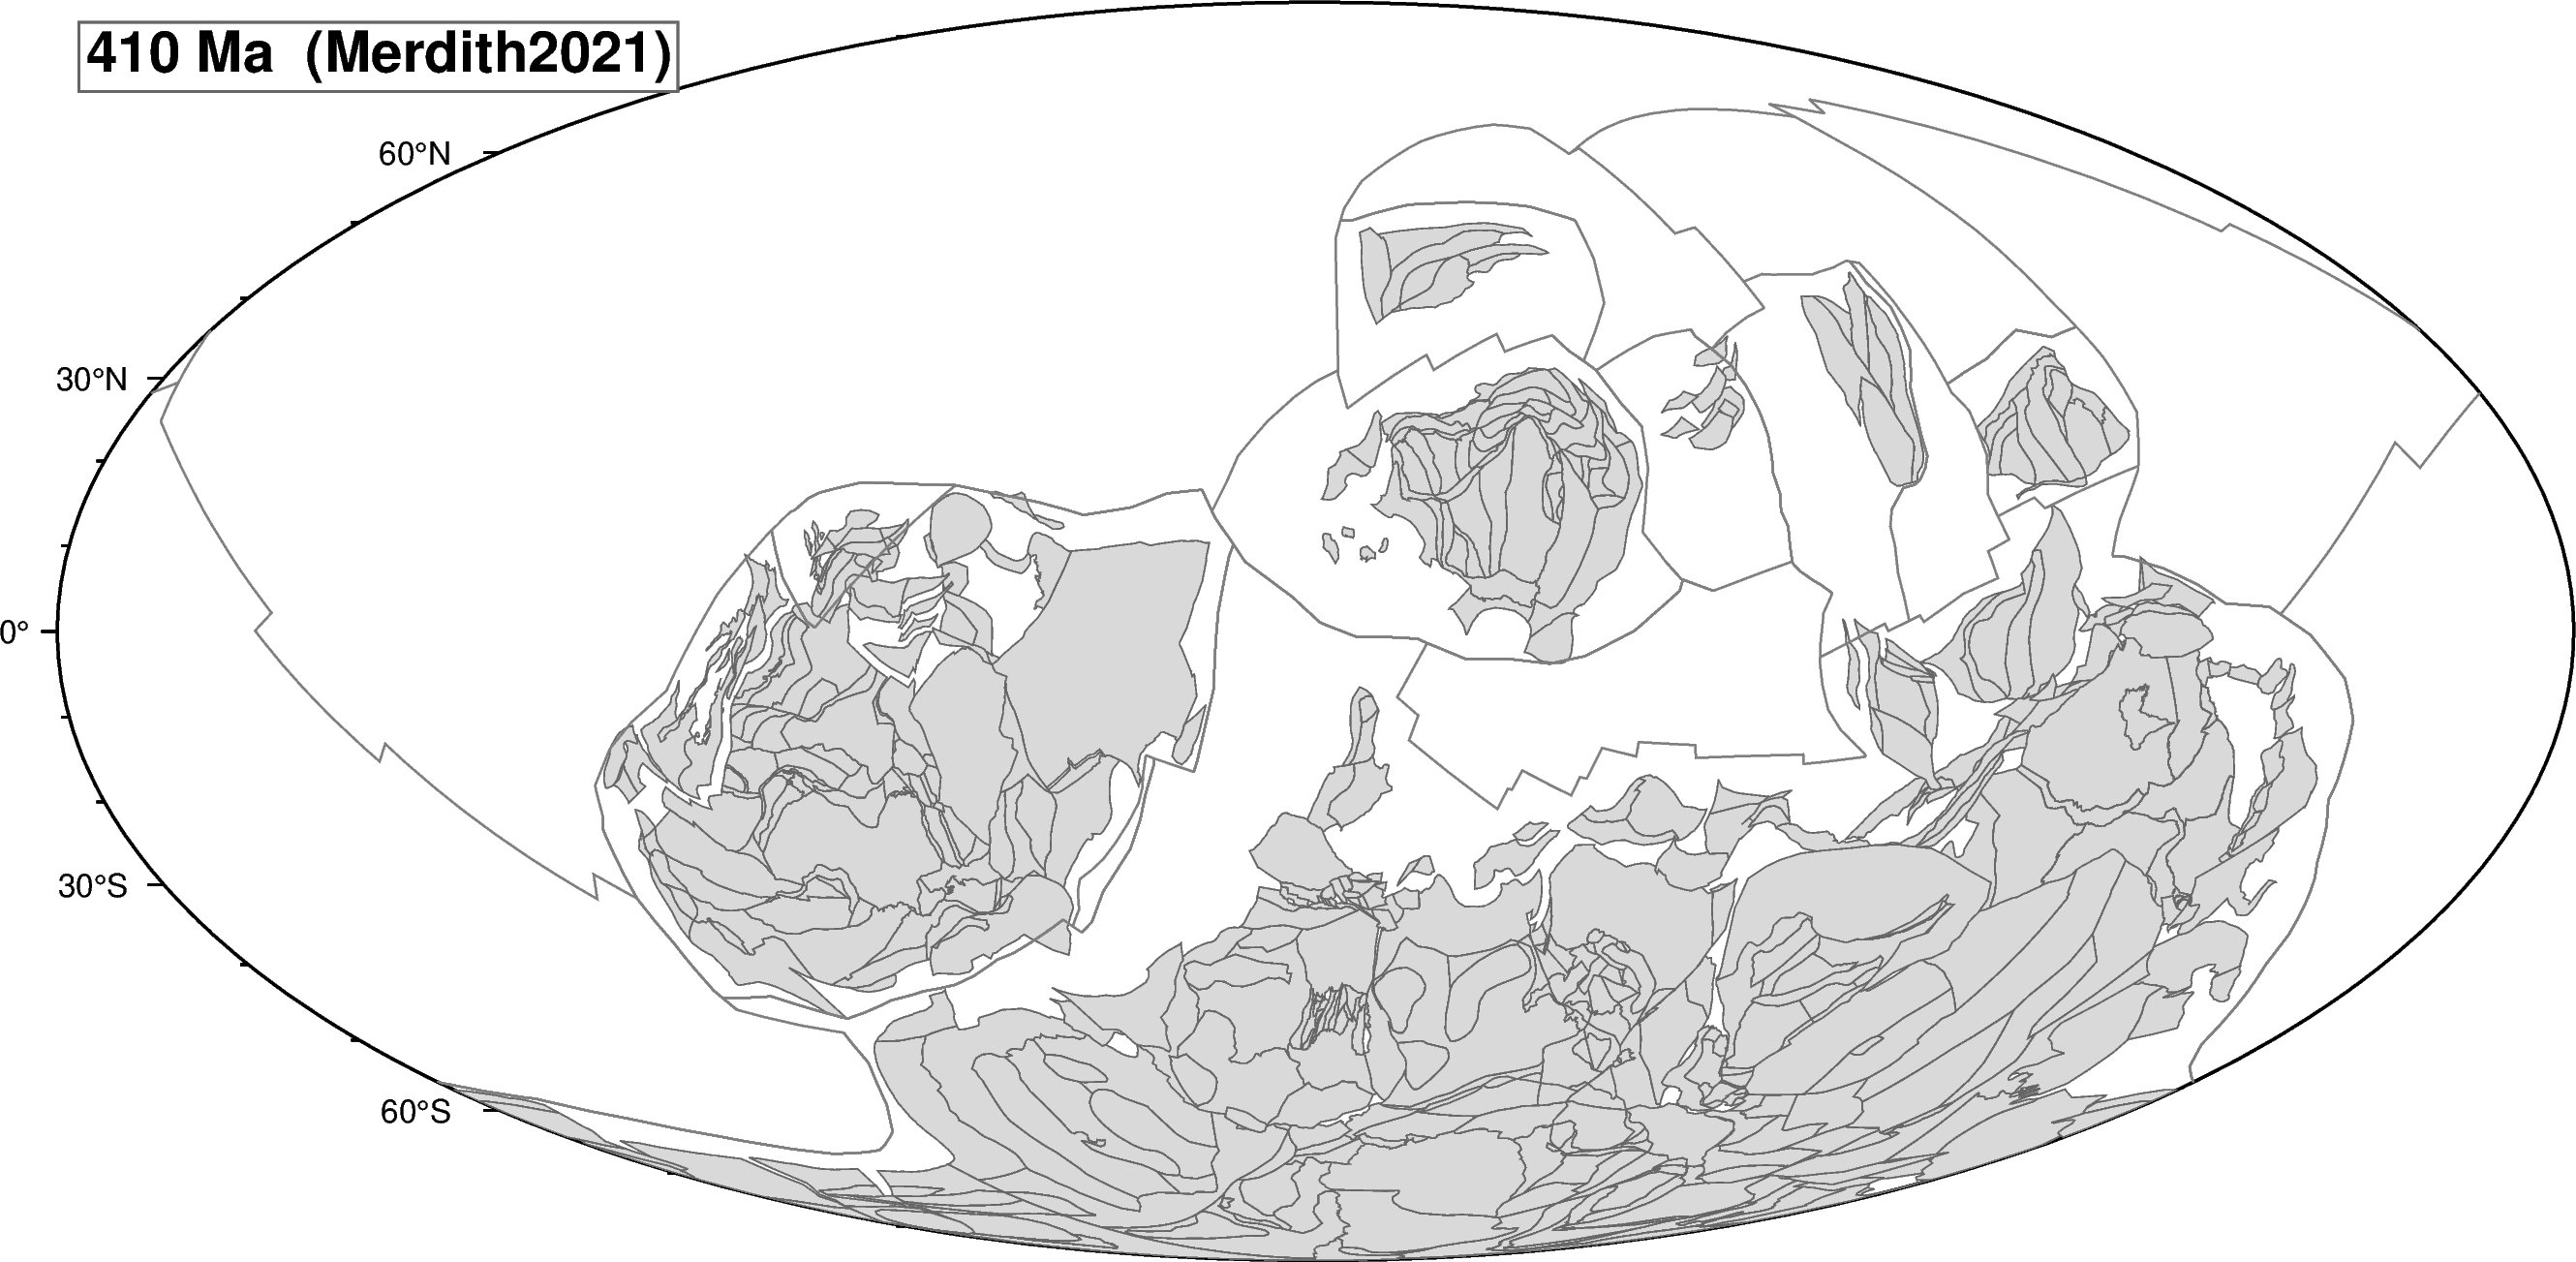

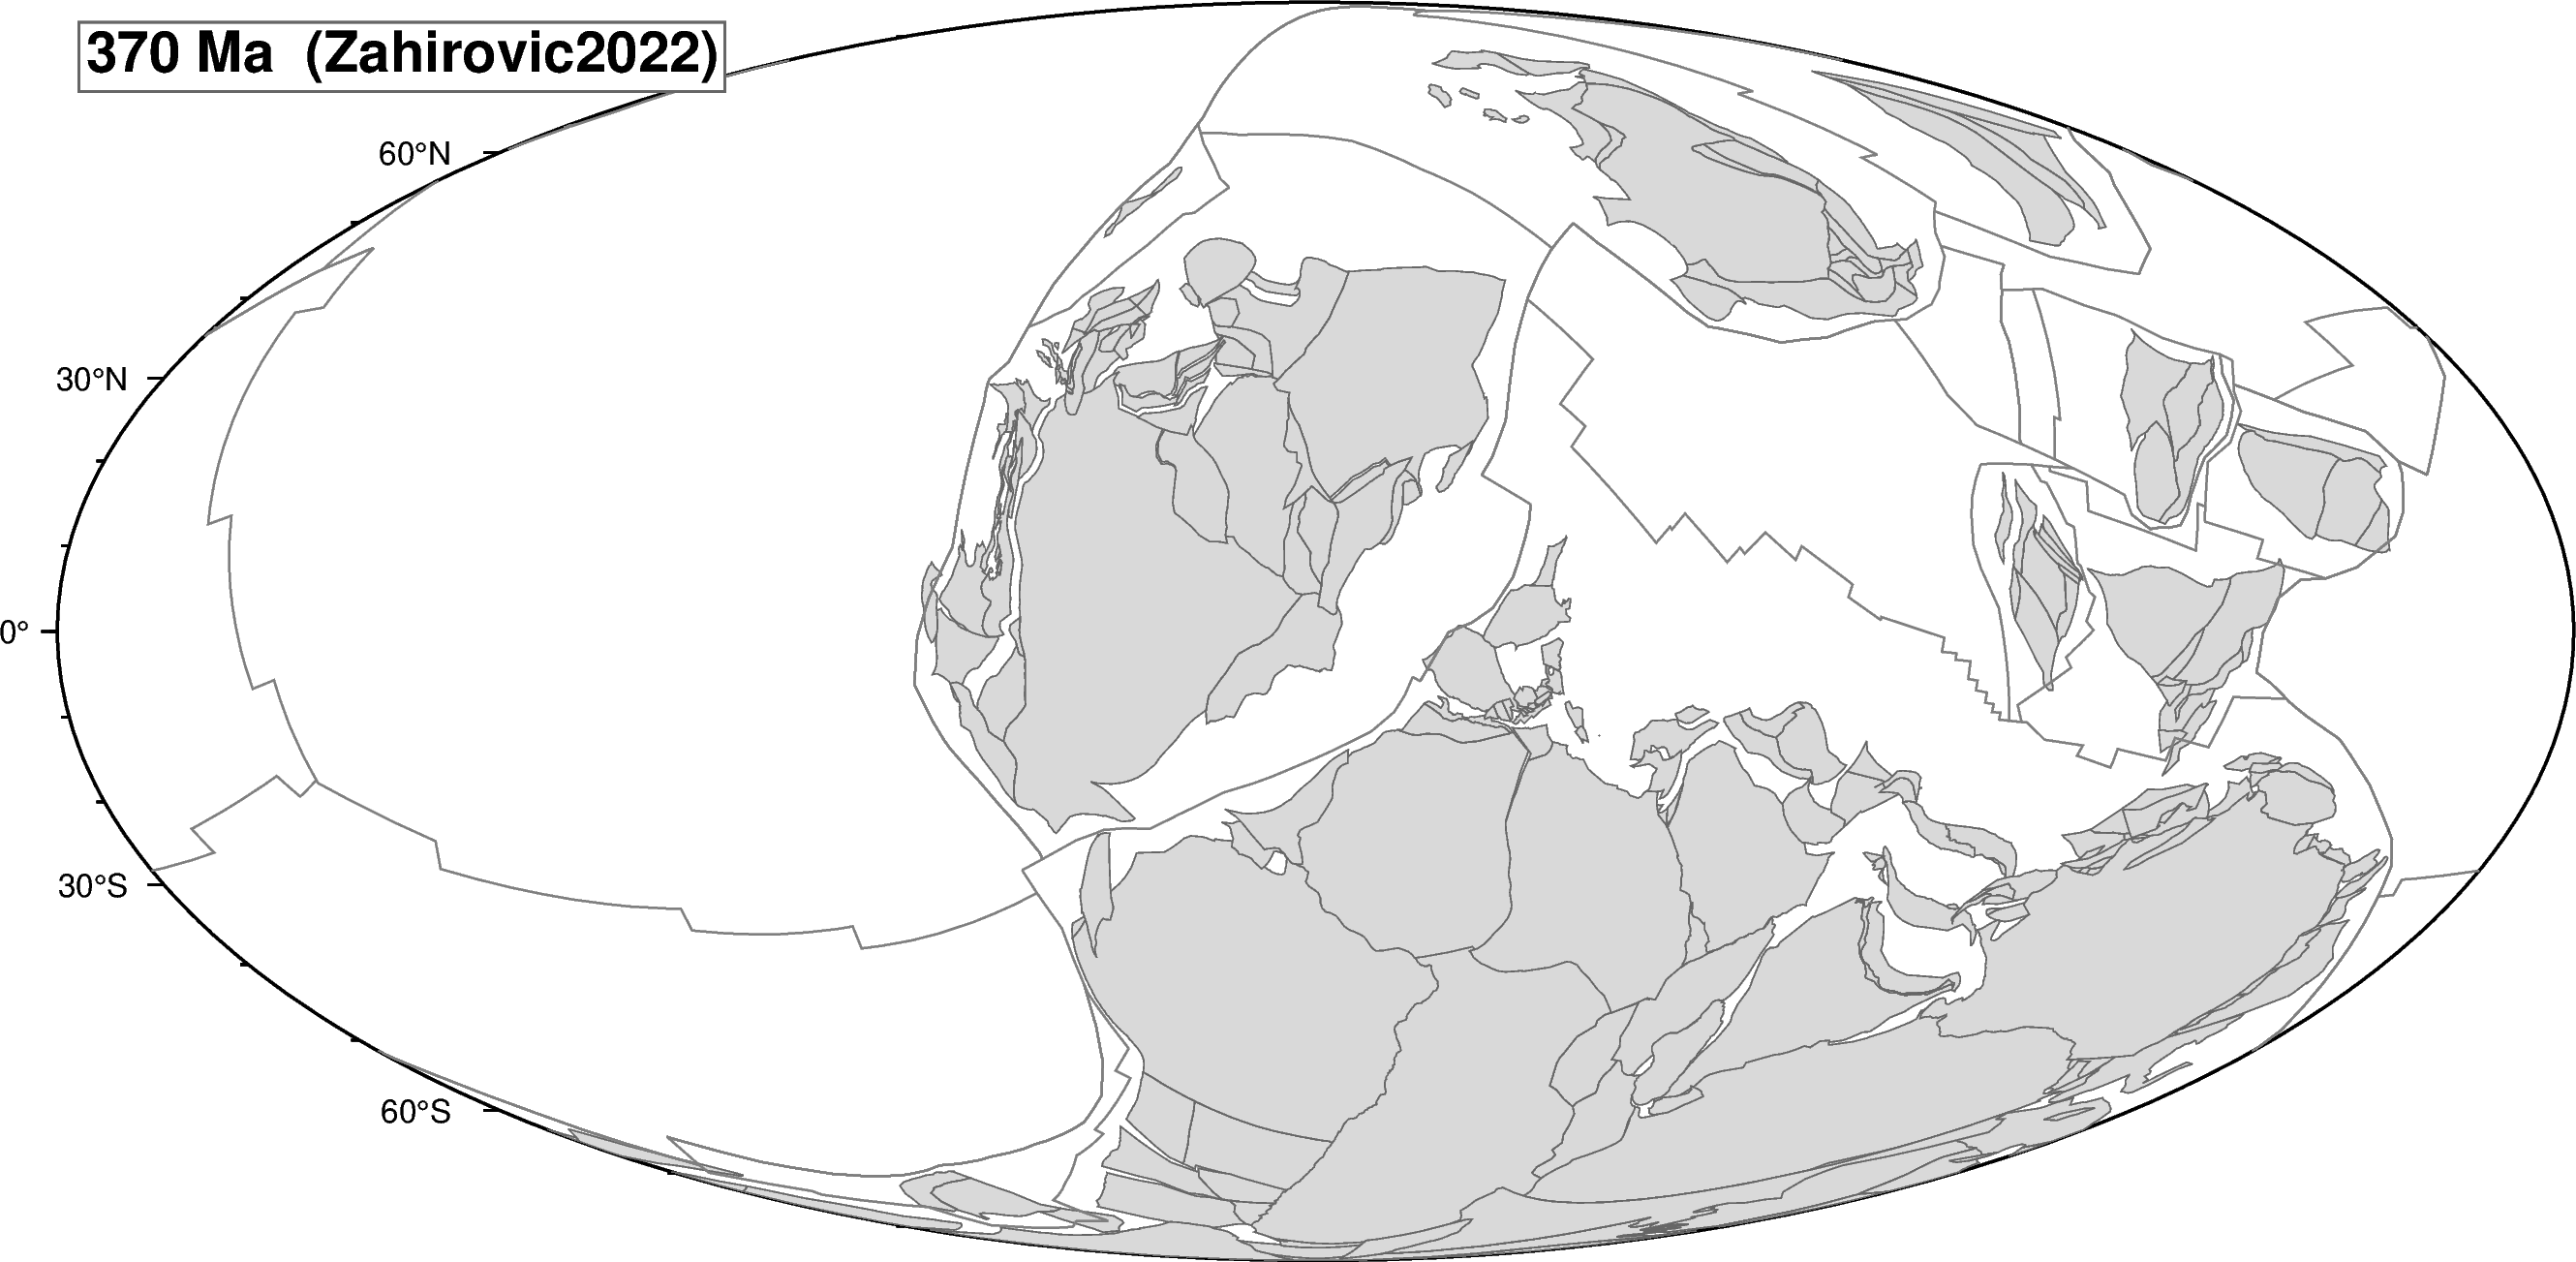

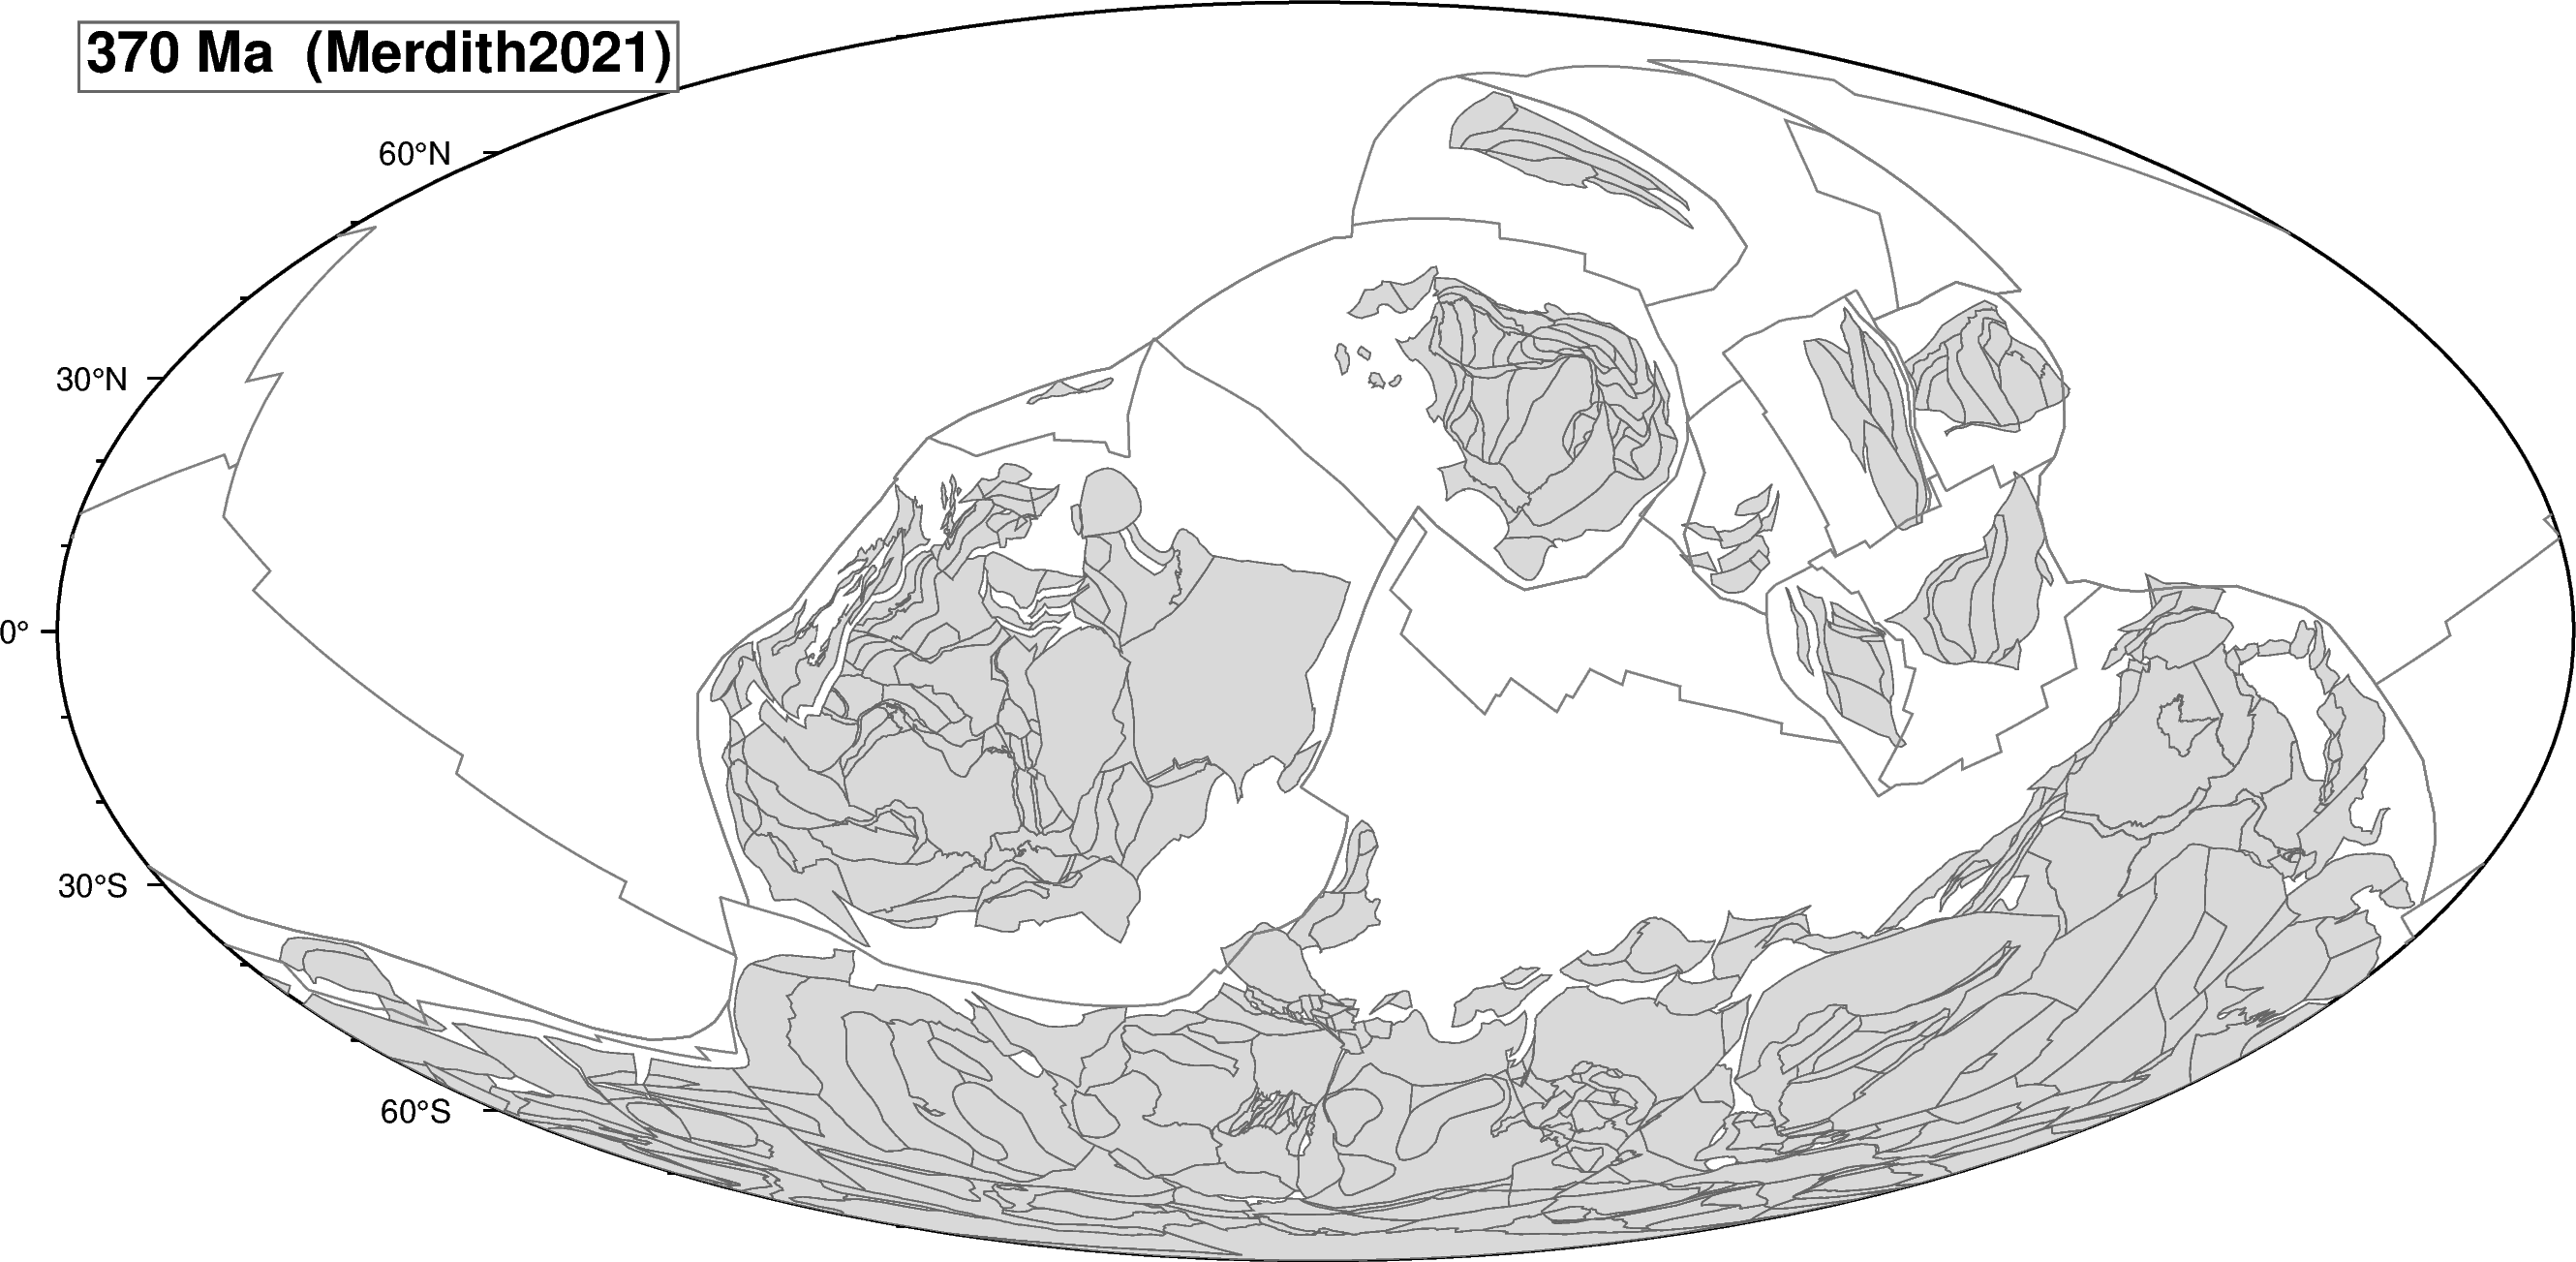

In [4]:
# Cell 3 — render the 2x2
for t in SNAPSHOT_TIMES:
    for model_name, recon, m in [(MODEL_A, reconA, mA), (MODEL_B, reconB, mB)]:
        gplot = gplately.PlotTopologies(
            plate_reconstruction=recon,
            coastlines=m.get_coastlines(),
            continents=m.get_continental_polygons(),
            COBs=m.get_COBs(),
            time=float(t))
        fig = pygmt.Figure()
        fig.basemap(region="d", projection="W0/22c", frame=["af"])
        engine.plot_geo_data_frame(fig, gplot.get_continents(),
                                   fill="gray85", pen="0.3p,gray40")
        engine.plot_geo_data_frame(fig, gplot.get_all_topological_sections(),
                                   pen="0.5p,gray50")
        fig.text(text=f"{t:.0f} Ma  ({model_name})",
                 position="TL", offset="0.25c/-0.25c", justify="TL",
                 font="14p,Helvetica-Bold,black",
                 fill="white", pen="0.6p,gray40")
        fig.show(width=900)
        display(HTML('<div style="height:1cm"></div>'))


## 3. DT difference field at each age

  410 Ma  displacement: median 3621 km, 95th %ile 6783 km, max 8899 km


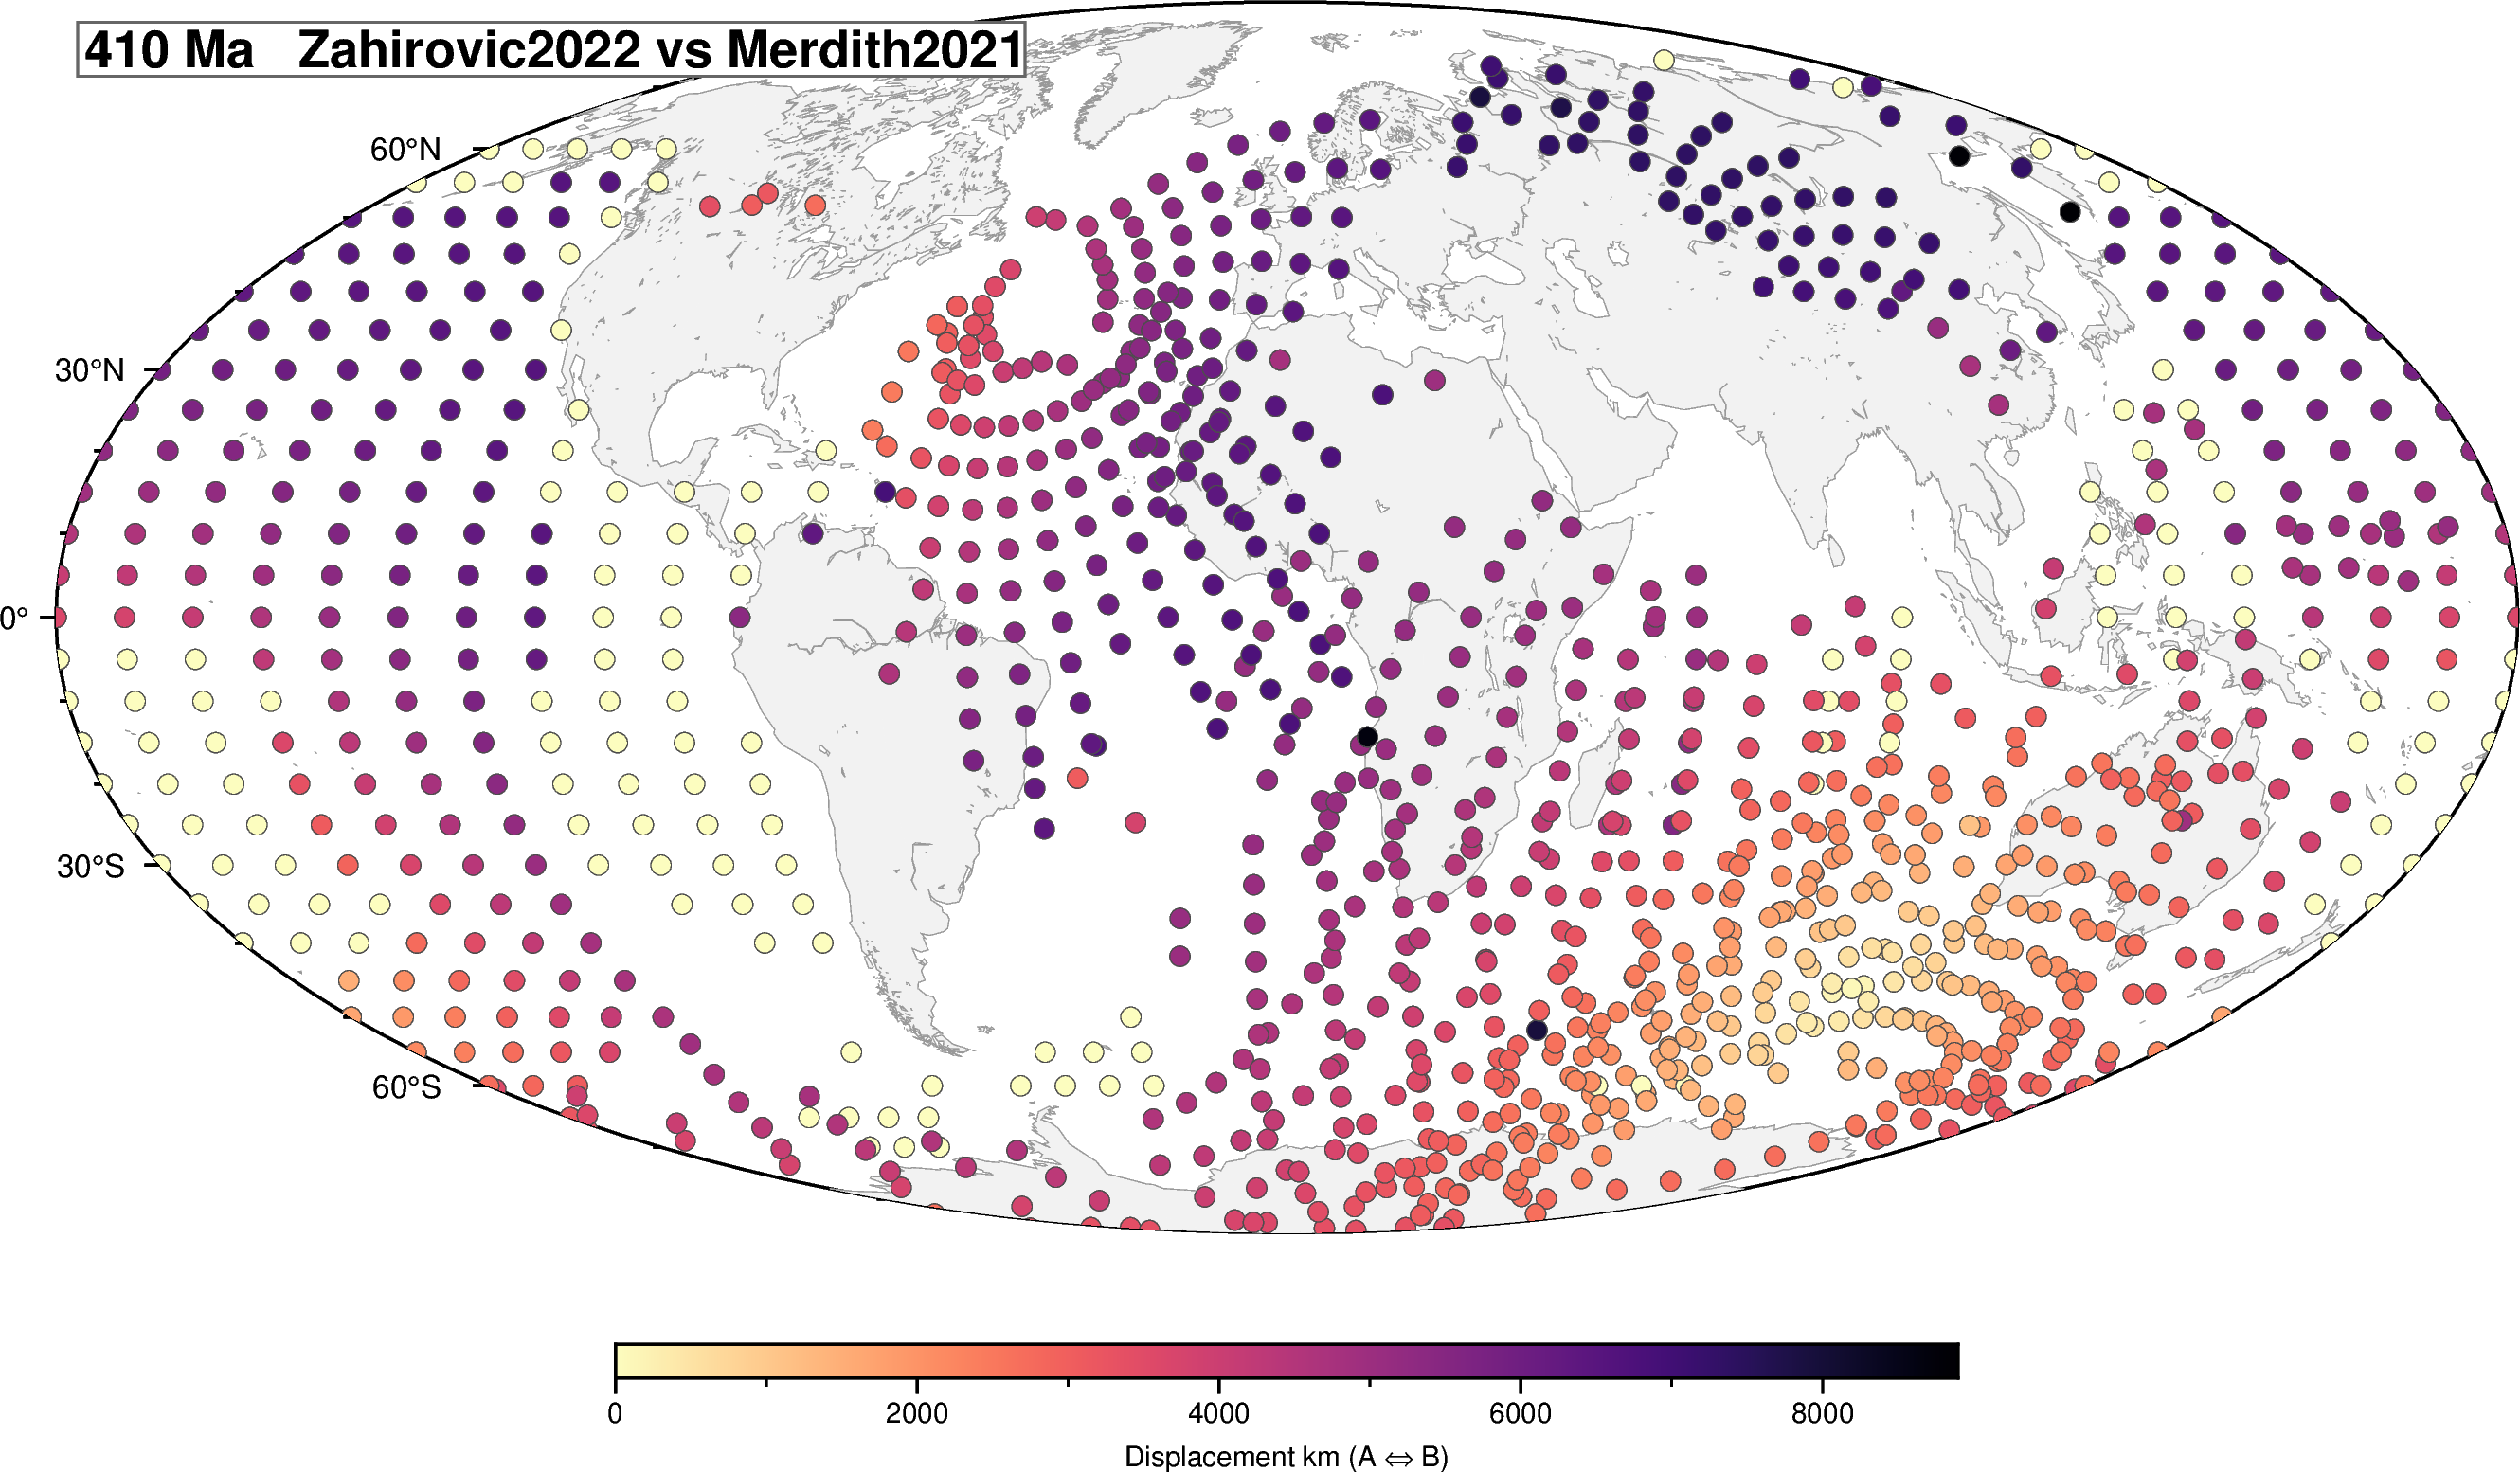

  370 Ma  displacement: median 3799 km, 95th %ile 5692 km, max 8973 km


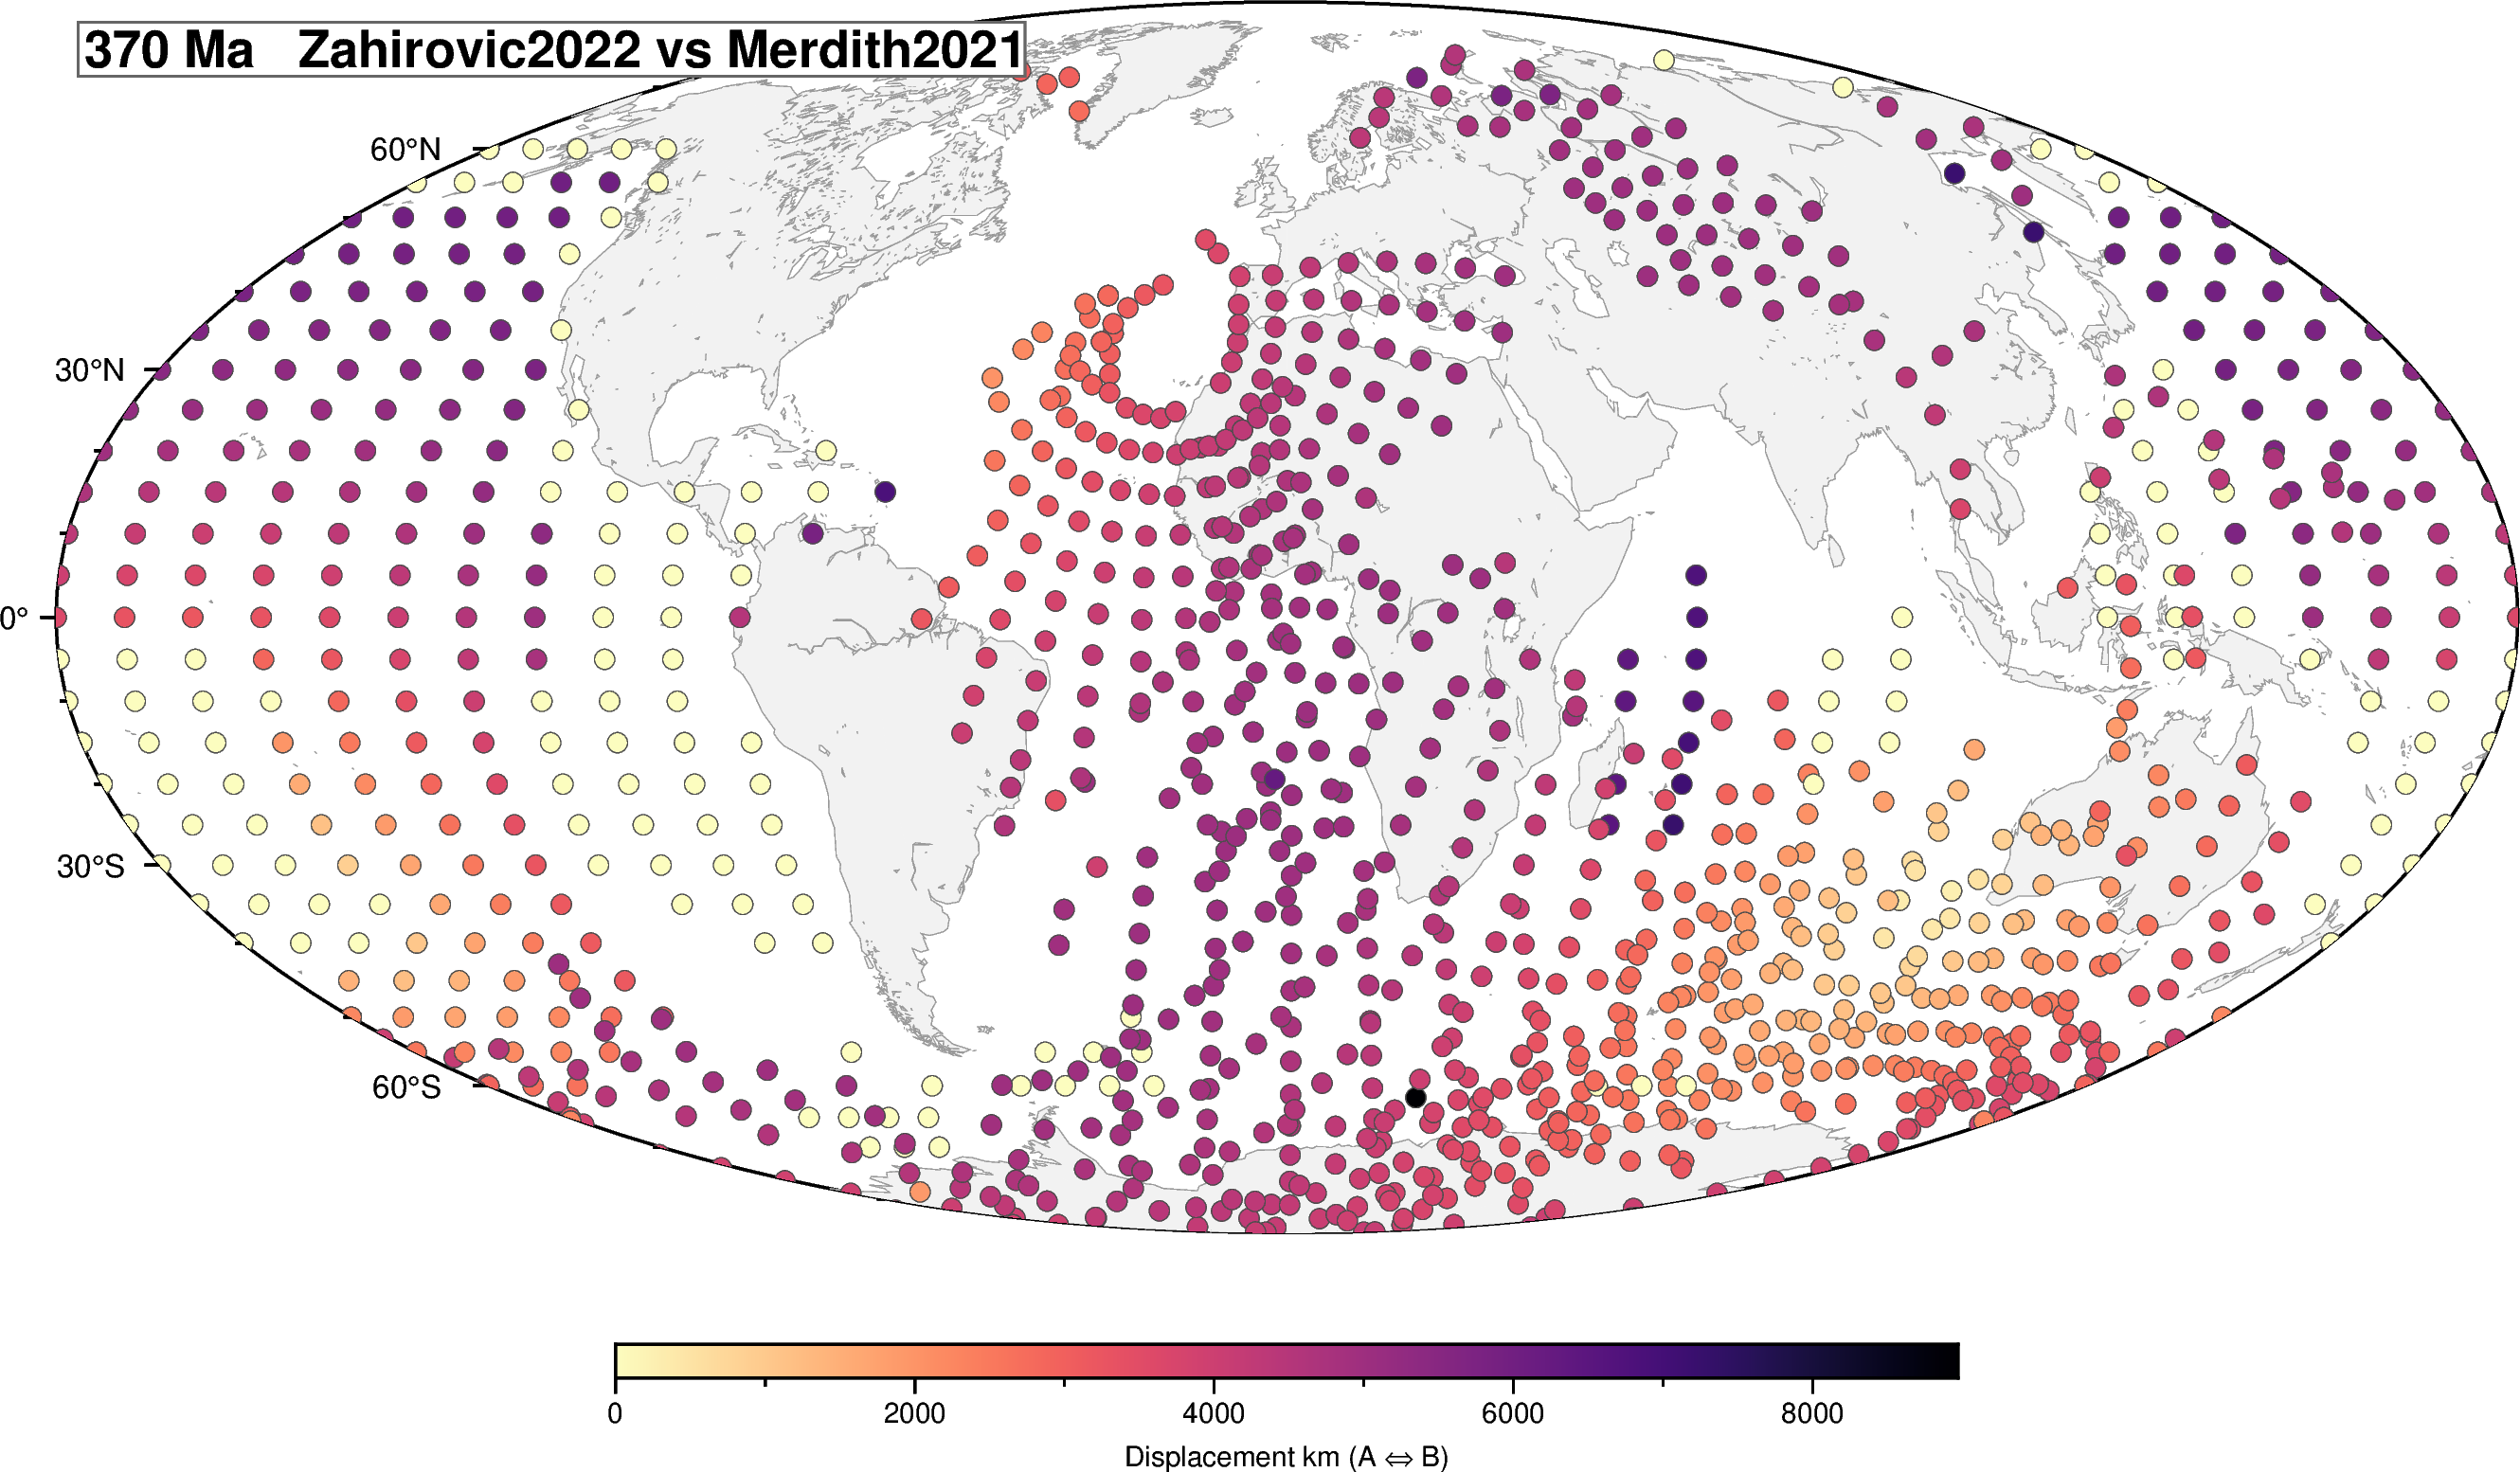

In [5]:
# Cell 4 — quantitative model-vs-model displacement
# For each snapshot age, sample a dense grid of points across the
# globe, reconstruct each one through BOTH models, and measure the
# great-circle distance between the two predicted paleo-positions.
# Larger displacement = the two models disagree more about where this
# point was at that age.
def gc_dist_deg(lon1, lat1, lon2, lat2):
    """Great-circle distance in degrees between two arrays of points."""
    a1, b1 = np.deg2rad(lat1), np.deg2rad(lon1)
    a2, b2 = np.deg2rad(lat2), np.deg2rad(lon2)
    d = np.arccos(np.clip(
        np.sin(a1) * np.sin(a2)
        + np.cos(a1) * np.cos(a2) * np.cos(b2 - b1), -1.0, 1.0))
    return np.rad2deg(d)


grid_lats = np.arange(-75.0, 75.001, 5.0)
grid_lons = np.arange(-180.0, 180.001, 10.0)
LATG, LONG = np.meshgrid(grid_lats, grid_lons, indexing="ij")
sample_lats = LATG.flatten()
sample_lons = LONG.flatten()

ptsA = gplately.Points(reconA, sample_lons, sample_lats)
ptsB = gplately.Points(reconB, sample_lons, sample_lats)

for t in SNAPSHOT_TIMES:
    rlonA, rlatA = ptsA.reconstruct(float(t), return_array=True)
    rlonB, rlatB = ptsB.reconstruct(float(t), return_array=True)
    n = min(len(rlonA), len(rlonB))    # trim if either silently dropped points
    disp_deg = gc_dist_deg(rlonA[:n], rlatA[:n],
                           rlonB[:n], rlatB[:n])
    disp_km = disp_deg * 111.32  # 1 degree ≈ 111.32 km on Earth's surface

    fig = pygmt.Figure()
    fig.basemap(region="d", projection="W0/22c", frame=["af"])
    fig.coast(land="gray95", shorelines="0.2p,gray60", resolution="c")
    pygmt.makecpt(cmap="magma", series=[0, max(50, float(np.nanmax(disp_km))), 1],
                  background="o", continuous=True, reverse=True)
    fig.plot(x=rlonA[:n], y=rlatA[:n], style="c0.18c",
             fill=disp_km, cmap=True, pen="0.2p,gray30")
    fig.colorbar(frame="af+lDisplacement km (A \u21d4 B)",
                 position="JBC+w12c/0.3c+h+o0/1c")
    fig.text(text=f"{t:.0f} Ma   {MODEL_A} vs {MODEL_B}",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="13p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40")
    print(f"  {t:.0f} Ma  displacement: "
          f"median {np.nanmedian(disp_km):.0f} km, "
          f"95th %ile {np.nanpercentile(disp_km, 95):.0f} km, "
          f"max {np.nanmax(disp_km):.0f} km")
    fig.show(width=1000)
    display(HTML('<div style="height:0.6cm"></div>'))


## Extend this

- **Three-way comparison.** Add a third model (e.g. `"Muller2022"`) and render a 2 × 3 grid.
- **Sweep all ages.** Loop over the full coverage interval and animate the model-to-model difference as a function of time.
- **Quantitative metric.** Compute the global RMS of the DT difference field as a function of time; this is a single-number summary of how much paleo-geography depends on the rotation-model choice at each age.
- **Cross-reference T04.** T04 already does a multi-model diff map at one time. T05 generalises it to the dynamic-topography field instead of static topology.

## References

- Dhungana, S. & Flament, N. (2025). The deep Earth origin of the Great Unconformity. *JGR — Solid Earth* (in press).
- Merdith, A.S. et al. (2021). Extending full-plate tectonic models into deep time: Linking the Neoproterozoic and the Phanerozoic. *Earth-Science Reviews* 214, 103477.
- Cao, X. et al. (2024). A deep-time Phanerozoic to Proterozoic plate motion model. *ESSD* 16, 4007–4032.
- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11(1), 3–10. https://doi.org/10.1002/gdj3.185
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Tong, J.-H., Ngo, L., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J. & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.10578540
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515
- Chin, M., Mather, B.R. & Müller, R.D. (2024). Plate Model Manager: A Python package for downloading and managing plate reconstruction models. *Journal of Open Source Software* 9(101), 7090. https://doi.org/10.21105/joss.07090
